In [644]:
import pandas as pd
import numpy as np
import re
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Load datasets
amazon_df = pd.read_csv('fake reviews dataset.csv')
yelp_df = pd.read_csv('Labelled Yelp Dataset.csv')

# Quick view
print("Amazon shape:", amazon_df.shape)
print("Yelp shape:", yelp_df.shape)


Amazon shape: (40432, 4)
Yelp shape: (359052, 6)


In [645]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [646]:
amazon_df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfortable. I love it!Very pretty"
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I've had mine for a couple of years"
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and feel of this pillow.
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it is a great product for the price! I"
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the set for two months now and have not been


In [647]:
yelp_df.head()

,User_id,Product_id,Rating,Date,Review,Label
0,923,0,3,12/8/2014,The food at snack is a selection of popular Greek dishes. The appetizer tray is good as is the Greek salad. We were underwhelmed with the main courses. There are 4-5 tables here so it's sometimes ...,-1
1,924,0,3,5/16/2013,"This little place in Soho is wonderful. I had a lamb sandwich and a glass of wine. The price shocked me for how small the serving was, but then again, this is Soho. The staff can be a little snott...",-1
2,925,0,4,7/1/2013,"ordered lunch for 15 from Snack last Friday. Â On time, nothing missing and the food was great. Â I have added it to the regular company lunch list, as everyone enjoyed their meal.",-1
3,926,0,4,7/28/2011,"This is a beautiful quaint little restaurant on a pretty street. Â If you're strolling through soho around lunchtime, this would be a great place to stop for a bite. I heard the reviews about the ...",-1
4,927,0,4,11/1/2010,Snack is great place for a Â casual sit down lunch- especially on a cold winter day. Â In many ways the restaurant mirrors the food- simple yet unique. Â The avgolemono soup was lemony perfection ...,-1


In [648]:
print("Column Names:\n")
print(amazon_df.columns.tolist())

print("\nDataset Info:\n")
amazon_df.info()

print("\nMissing Values:\n")
print(amazon_df.isnull().sum())

Column Names:

['category', 'rating', 'label', 'text_']

Dataset Info:

<class 'pandas.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  str    
 1   rating    40432 non-null  float64
 2   label     40432 non-null  str    
 3   text_     40432 non-null  str    
dtypes: float64(1), str(3)
memory usage: 15.5 MB

Missing Values:

category    0
rating      0
label       0
text_       0
dtype: int64


In [649]:
print("Column Names:\n")
print(yelp_df.columns.tolist())

print("\nDataset Info:\n")
yelp_df.info()

print("\nMissing Values:\n")
print(yelp_df.isnull().sum())

Column Names:

['User_id', 'Product_id', 'Rating', 'Date', 'Review', 'Label']

Dataset Info:

<class 'pandas.DataFrame'>
RangeIndex: 359052 entries, 0 to 359051
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   User_id     359052 non-null  int64
 1   Product_id  359052 non-null  int64
 2   Rating      359052 non-null  int64
 3   Date        359052 non-null  str  
 4   Review      359052 non-null  str  
 5   Label       359052 non-null  int64
dtypes: int64(4), str(2)
memory usage: 239.0 MB

Missing Values:

User_id       0
Product_id    0
Rating        0
Date          0
Review        0
Label         0
dtype: int64


### Label Encoding

 1 = fake/AI-generated, 0 = genuine

In [650]:
label_map={'CG':1,'OR':0}
amazon_df['label']=amazon_df['label'].map(label_map)
amazon_df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,1,"Love this! Well made, sturdy, and very comfortable. I love it!Very pretty"
1,Home_and_Kitchen_5,5.0,1,"love it, a great upgrade from the original. I've had mine for a couple of years"
2,Home_and_Kitchen_5,5.0,1,This pillow saved my back. I love the look and feel of this pillow.
3,Home_and_Kitchen_5,1.0,1,"Missing information on how to use it, but it is a great product for the price! I"
4,Home_and_Kitchen_5,5.0,1,Very nice set. Good quality. We have had the set for two months now and have not been


 ### Column Standardization

In [651]:
#Amazon rename and remove unwanted columns

amazon_df = amazon_df.rename(columns={
    "text_": "review"
})
 
amazon_df = amazon_df[["rating","review","label"]]

amazon_df.head()

,rating,review,label
0,5.0,"Love this! Well made, sturdy, and very comfortable. I love it!Very pretty",1
1,5.0,"love it, a great upgrade from the original. I've had mine for a couple of years",1
2,5.0,This pillow saved my back. I love the look and feel of this pillow.,1
3,1.0,"Missing information on how to use it, but it is a great product for the price! I",1
4,5.0,Very nice set. Good quality. We have had the set for two months now and have not been,1


In [652]:
#Yelp rename and remove unwanted columns

yelp_df=yelp_df.rename(columns={
    "Rating":"rating",
    "Review":"review",
    "Label":"label"
})

yelp_df=yelp_df[["rating","review","label"]]

yelp_df.head()

,rating,review,label
0,3,The food at snack is a selection of popular Greek dishes. The appetizer tray is good as is the Greek salad. We were underwhelmed with the main courses. There are 4-5 tables here so it's sometimes ...,-1
1,3,"This little place in Soho is wonderful. I had a lamb sandwich and a glass of wine. The price shocked me for how small the serving was, but then again, this is Soho. The staff can be a little snott...",-1
2,4,"ordered lunch for 15 from Snack last Friday. Â On time, nothing missing and the food was great. Â I have added it to the regular company lunch list, as everyone enjoyed their meal.",-1
3,4,"This is a beautiful quaint little restaurant on a pretty street. Â If you're strolling through soho around lunchtime, this would be a great place to stop for a bite. I heard the reviews about the ...",-1
4,4,Snack is great place for a Â casual sit down lunch- especially on a cold winter day. Â In many ways the restaurant mirrors the food- simple yet unique. Â The avgolemono soup was lemony perfection ...,-1


In [653]:
label_map={-1:1,1:0}
yelp_df['label']=yelp_df['label'].map(label_map)
yelp_df.head()

,rating,review,label
0,3,The food at snack is a selection of popular Greek dishes. The appetizer tray is good as is the Greek salad. We were underwhelmed with the main courses. There are 4-5 tables here so it's sometimes ...,1
1,3,"This little place in Soho is wonderful. I had a lamb sandwich and a glass of wine. The price shocked me for how small the serving was, but then again, this is Soho. The staff can be a little snott...",1
2,4,"ordered lunch for 15 from Snack last Friday. Â On time, nothing missing and the food was great. Â I have added it to the regular company lunch list, as everyone enjoyed their meal.",1
3,4,"This is a beautiful quaint little restaurant on a pretty street. Â If you're strolling through soho around lunchtime, this would be a great place to stop for a bite. I heard the reviews about the ...",1
4,4,Snack is great place for a Â casual sit down lunch- especially on a cold winter day. Â In many ways the restaurant mirrors the food- simple yet unique. Â The avgolemono soup was lemony perfection ...,1


In [654]:
amazon_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   rating  40432 non-null  float64
 1   review  40432 non-null  str    
 2   label   40432 non-null  int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 14.5 MB


In [655]:
amazon_df["rating"].unique()

array([5., 1., 3., 2., 4.])

In [656]:
amazon_df["rating"]=amazon_df["rating"].astype(int)

In [657]:
yelp_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 359052 entries, 0 to 359051
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   rating  359052 non-null  int64
 1   review  359052 non-null  str  
 2   label   359052 non-null  int64
dtypes: int64(2), str(1)
memory usage: 227.7 MB


### Duplicate Removal

In [658]:
print("Duplicates Before:", amazon_df.duplicated().sum())

Duplicates Before: 12


In [659]:
amazon_df = amazon_df.drop_duplicates(subset="review").reset_index(drop=True)

print("Dataset Shape After Removing Duplicates:", amazon_df.shape)

Dataset Shape After Removing Duplicates: (40412, 3)


In [660]:
print("Duplicates Before:", yelp_df.duplicated().sum())

Duplicates Before: 469


In [661]:
yelp_df = yelp_df.drop_duplicates(subset="review").reset_index(drop=True)

print("Dataset Shape After Removing Duplicates:", yelp_df.shape)

Dataset Shape After Removing Duplicates: (358156, 3)


### Text Cleaning

In [662]:
def count_patterns(df, column):
    # Convert column to string (ignore NaN issues)
    text = df[column].fillna("").astype(str)

    html_count = text.str.contains(r"<.*?>", regex=True).sum()
    url_count = text.str.contains(r"http\S+|www\.\S+", regex=True).sum()
    email_count = text.str.contains(r"\S+@\S+", regex=True).sum()

    print(f"Total rows: {len(df)}")
    print(f"Rows with HTML tags   : {html_count}")
    print(f"Rows with URLs        : {url_count}")
    print(f"Rows with Email IDs   : {email_count}")

    return {
        "html_tags": html_count,
        "urls": url_count,
        "emails": email_count
    }

In [663]:
print(count_patterns(amazon_df, "review"))
print(count_patterns(yelp_df, "review"))

Total rows: 40412
Rows with HTML tags   : 203
Rows with URLs        : 109
Rows with Email IDs   : 11
{'html_tags': np.int64(203), 'urls': np.int64(109), 'emails': np.int64(11)}
Total rows: 358156
Rows with HTML tags   : 0
Rows with URLs        : 33
Rows with Email IDs   : 215
{'html_tags': np.int64(0), 'urls': np.int64(33), 'emails': np.int64(215)}


In [664]:
import html

def clean_review(text):
    # Convert to string
    text = str(text)

    # Decode HTML entities
    text = html.unescape(text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\\S+|www\\.\\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\\S+@\\S+", " ", text)

    # Fix common encoding artifacts
    text = re.sub(r"[ÂâÃ]+", " ", text)
    
    # Remove all remaining non-ASCII characters (optional)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    
    # Remove extra spaces/newlines/tabs
    text = re.sub(r"\\s+", " ", text).strip()
    
    # Remove newline, tab, and extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Remove special symbols/punctuation and replace with a space
    text = re.sub(r"[^\w\s]", " ", text)

    # Collapse multiple spaces created after removing symbols
    text = re.sub(r"\s+", " ", text).strip()
    
    # Lowercase only
    text = text.lower()

    return text

In [665]:
amazon_df["review"] = amazon_df["review"].apply(clean_review)

In [666]:
yelp_df["review"] = yelp_df["review"].apply(clean_review)

In [667]:
amazon_df = amazon_df[amazon_df["review"].str.len() > 0].reset_index(drop=True)

print("Dataset Shape:", amazon_df.shape)

Dataset Shape: (40411, 3)


In [668]:
yelp_df = yelp_df[yelp_df["review"].str.len() > 0].reset_index(drop=True)

print("Dataset Shape:", yelp_df.shape)

Dataset Shape: (358142, 3)


### Class Distribution

In [669]:
label_counts = amazon_df["label"].value_counts().sort_index()

print(label_counts)

print("\nPercentage Distribution:")
print((label_counts / len(amazon_df) * 100).round(2))

label
0    20215
1    20196
Name: count, dtype: int64

Percentage Distribution:
label
0    50.02
1    49.98
Name: count, dtype: float64


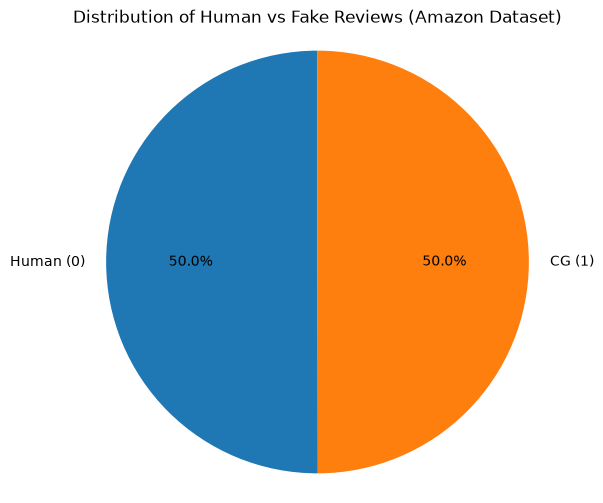

In [670]:
label_counts = amazon_df["label"].value_counts().sort_index()

# Pie chart
plt.figure(figsize=(6, 6))

plt.pie(
    label_counts,
    labels=["Human (0)", "CG (1)"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Human vs Fake Reviews (Amazon Dataset)")
plt.axis("equal")

plt.show()

In [671]:
label_counts = yelp_df["label"].value_counts().sort_index()

print(label_counts)

print("\nPercentage Distribution:")
print((label_counts / len(yelp_df) * 100).round(2))

label
0    321568
1     36574
Name: count, dtype: int64

Percentage Distribution:
label
0    89.79
1    10.21
Name: count, dtype: float64


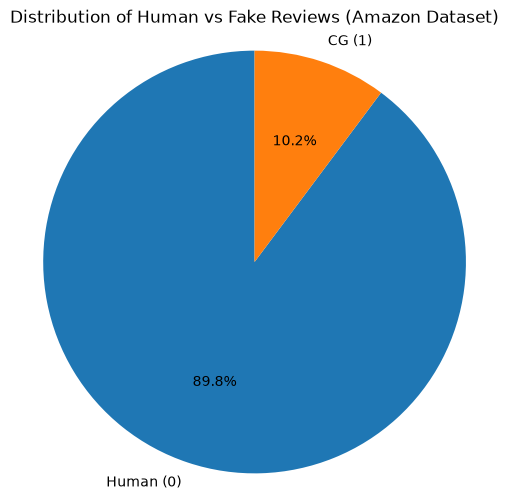

In [672]:
label_counts = yelp_df["label"].value_counts().sort_index()

# Pie chart
plt.figure(figsize=(6, 6))

plt.pie(
    label_counts,
    labels=["Human (0)", "CG (1)"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Human vs Fake Reviews (Amazon Dataset)")
plt.axis("equal")

plt.show()

#### Balance Yelp Dataset


randomly sample 25k from each class to create a balanced subset, since the original Yelp data is heavily skewed (~90% genuine)

In [673]:
fake = yelp_df[yelp_df['label'] == 0].sample(n=25000, random_state=42)
real = yelp_df[yelp_df['label'] == 1].sample(n=25000, random_state=42)

yelp_sample = (
    pd.concat([fake, real])
      .sample(frac=1, random_state=42)   # shuffle
      .reset_index(drop=True)
)
print("Label counts:\n", yelp_sample['label'].value_counts())

Label counts:
 label
1    25000
0    25000
Name: count, dtype: int64


In [674]:
print("Label counts:\n", amazon_df['label'].value_counts())

Label counts:
 label
0    20215
1    20196
Name: count, dtype: int64


### Review Length Filtering

In [675]:
#amazon

print("Empty Reviews :", (amazon_df["review"] == "").sum())

print("Average Review Length :", amazon_df["review"].str.len().mean())

print("Shortest Review Length :", amazon_df["review"].str.len().min())

print("Longest Review Length :", amazon_df["review"].str.len().max())

Empty Reviews : 0
Average Review Length : 339.90292247160426
Shortest Review Length : 4
Longest Review Length : 2095


In [676]:
# Print rows where text has fewer than 20 characters
amazon_df[amazon_df["review"].str.len() < 20]

,rating,review,label
9907,5,input,1
18615,3,pfister lf 042 prcc,1
21677,5,well,1
36815,5,nice elegant watch,1


In [677]:
amazon_df[amazon_df["review"].str.len() > 300]

,rating,review,label
2410,1,i had a hard time contacting the manufacturer distributor in order to make sure the measurements were correct the description and the pdf have completely different dimensions in reality these didn...,0
2578,5,i purchased this bed and have slept on it for the past week i believe in trying things out to make sure my guests won t suffer from backaches etc the aerobed provides a comfortable night s rest i ...,0
2605,4,after my first night sleeping on a neckbone pillow i ordered another one so my husband could have his own too i could already feel improvement in my neck and shoulder problems after just one night...,0
2608,5,these canisters are the perfect size for us we use the smallest one for powdered creamer the middle size for instant coffee and the largest size for sugar which we use to refill our smaller sugar ...,0
2637,5,these are really wonderful they are perfect for strawberry hulling neatly and easily i ve owned a dozen not because they wear out they don t they just seem to wander away when i m not looking fort...,0
...,...,...,...
40406,4,i had read some reviews saying that this bra ran small and so i ordered two band and cup sizes up and it was still too small definitely along the lines of a sports bra squish effect the sides do c...,0
40407,5,i wasn t sure exactly what it would be it is a little large for my small size but i think it is a nice fit the fabric is a nice thin material but it is a little thin in the legs i wish it was thic...,1
40408,2,you can wear the hood by itself wear it with the hood or wear just the jacket without the hood how is that for 3 in 1 systems reminiscent of what lands end sells as a squall jacket or what uniform...,0
40409,1,i liked nothing about this dress the only reason i gave it 4 stars is because i ordered the size 6 5 and it fit perfectly the fabric is a nice thin material and the color is vibrant it s a little ...,1


In [678]:
long_reviews = amazon_df[amazon_df["review"].str.len() >300]

# Label counts
label_counts = long_reviews["label"].value_counts().sort_index()

print("Label Distribution (Count):")
print(label_counts)

print("\nLabel Distribution (Percentage):")
print((label_counts / len(long_reviews) * 100).round(2))

Label Distribution (Count):
label
0    7819
1    6231
Name: count, dtype: int64

Label Distribution (Percentage):
label
0    55.65
1    44.35
Name: count, dtype: float64


In [679]:
#yelp

print("Empty Reviews :", (yelp_sample["review"] == "").sum())

print("Average Review Length :", yelp_sample["review"].str.len().mean())

print("Shortest Review Length :", yelp_sample["review"].str.len().min())

print("Longest Review Length :", yelp_sample["review"].str.len().max())

Empty Reviews : 0
Average Review Length : 529.96384
Shortest Review Length : 1
Longest Review Length : 4907


In [680]:
# Print rows where text has fewer than 20 characters
yelp_sample[yelp_sample["review"].str.len() < 20]

,rating,review,label
56,5,still the best,1
75,5,love this place,1
421,5,5,1
854,5,great place,1
908,3,i like the drinks,1
...,...,...,...
49848,5,excellent,1
49858,5,love it,0
49877,5,yum,1
49961,4,nom,1


In [681]:
short_yelp_reviews = yelp_sample[yelp_sample["review"].str.len() < 20]

# Label counts
label_counts = short_yelp_reviews["label"].value_counts().sort_index()

print("Label Distribution (Count):")
print(label_counts)

print("\nLabel Distribution (Percentage):")
print((label_counts / len(short_yelp_reviews) * 100).round(2))

Label Distribution (Count):
label
0    117
1    453
Name: count, dtype: int64

Label Distribution (Percentage):
label
0    20.53
1    79.47
Name: count, dtype: float64


In [682]:
yelp_sample[
    yelp_sample["review"].str.len() < 20
].assign(
    review_length=yelp_sample["review"].str.len()
).sort_values(
    by="review_length", ascending=False
)

,rating,review,label,review_length
48267,5,cheap and delicious,1,19
47366,5,very very very good,1,19
45673,5,great place love it,1,19
2359,3,white sauce is good,1,19
3039,4,i loved their tacos,1,19
...,...,...,...,...
40750,5,yum,0,3
49961,4,nom,1,3
44802,5,woo,1,3
23950,2,ok,1,2


In [683]:
yelp_sample[yelp_sample["review"].str.len() > 500]

,rating,review,label
1,2,the atmosphere is really great with the open kitchen and all but the hostess bartender and so called owner were too cool for school esp when you we made a reservation on opentable for a specific t...,0
2,3,very regular thai food the drinks aren t bad but they re pretty weak we came on a friday night and it was really busy so maybe the service wasn t normal but it was pretty horrible no one came to o...,0
3,2,i m not one to trash companies and i have loved this restaurant for years this gives them 2 stars instead of 1 i m posting my email which received a response after 2 days claiming they would follo...,0
5,1,i went to this restaurant last saturday based on the reviews that my friend saw on yelp well i can easily say that this is the worst food i have ever eaten at a restaurant i have no idea what thos...,1
6,4,place was nice looking staff were friendly and food was delicious we were seated in the main dining area as there were no seats available in the back yard a c was pumping and place was a bit chill...,0
...,...,...,...
49988,3,good very inexpensive basic cantonese food you can even eat healthy here if you are careful about what you order more of a lunch place than dinner if you care about cleanliness you will mind the s...,0
49989,2,david chang you may be slightly overrated went with a group of six we ordered 1 the kimchee w pears 2 hamachi 3 oysters w kimchee foam 4 the pork buns and of course 5 the pork shoulder the best by...,1
49990,5,first went to soco a few weeks before the grand opening the grand opening was in late july so im guessing late june is when i first went they were only open sporadically then and they were testing...,1
49992,5,a friend was in town and i learned this was her spot the must do thing on the line up having never been sounded good to me everything was under complete control here you walked in and you either h...,1


When detecting AI-generated reviews, very short texts provide insufficient linguistic signal to reliably distinguish between human and AI.

In [684]:
yelp_sample = yelp_sample[yelp_sample["review"].str.len() >= 20]

In [685]:
amazon_df=amazon_df[amazon_df["review"].str.len() >= 20]

In [686]:
#yelp

print("Empty Reviews :", (yelp_sample["review"] == "").sum())

print("Average Review Length :", yelp_sample["review"].str.len().mean())

print("Shortest Review Length :", yelp_sample["review"].str.len().min())

print("Longest Review Length :", yelp_sample["review"].str.len().max())

Empty Reviews : 0
Average Review Length : 535.9302043293546
Shortest Review Length : 20
Longest Review Length : 4907


In [687]:
#amazon

print("Empty Reviews :", (amazon_df["review"] == "").sum())

print("Average Review Length :", amazon_df["review"].str.len().mean())

print("Shortest Review Length :", amazon_df["review"].str.len().min())

print("Longest Review Length :", amazon_df["review"].str.len().max())

Empty Reviews : 0
Average Review Length : 339.9354319796075
Shortest Review Length : 24
Longest Review Length : 2095


### Exploratory Data Analysis

In [688]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

/opt/python-venvs/work/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/hitesh/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package punkt to /home/hitesh/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/hitesh/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [689]:
#amazon

print("Dataset Shape :", amazon_df.shape)
print("\nClass Distribution:\n")
print(amazon_df["label"].value_counts())

amazon_df.head()

Dataset Shape : (40407, 3)

Class Distribution:

label
0    20215
1    20192
Name: count, dtype: int64


,rating,review,label
0,5,love this well made sturdy and very comfortable i love it very pretty,1
1,5,love it a great upgrade from the original i ve had mine for a couple of years,1
2,5,this pillow saved my back i love the look and feel of this pillow,1
3,1,missing information on how to use it but it is a great product for the price i,1
4,5,very nice set good quality we have had the set for two months now and have not been,1


In [690]:
#Yelp

print("Dataset Shape :", yelp_sample.shape)
print("\nClass Distribution:\n")
print(yelp_sample["label"].value_counts())

yelp_sample.head()

Dataset Shape : (49430, 3)

Class Distribution:

label
0    24883
1    24547
Name: count, dtype: int64


,rating,review,label
0,5,my wife and i were told to check this place out we did just that last week and it was off the chain good part upscale grocery but not overpriced part i just stepped into italy and part amazing res...,1
1,2,the atmosphere is really great with the open kitchen and all but the hostess bartender and so called owner were too cool for school esp when you we made a reservation on opentable for a specific t...,0
2,3,very regular thai food the drinks aren t bad but they re pretty weak we came on a friday night and it was really busy so maybe the service wasn t normal but it was pretty horrible no one came to o...,0
3,2,i m not one to trash companies and i have loved this restaurant for years this gives them 2 stars instead of 1 i m posting my email which received a response after 2 days claiming they would follo...,0
4,5,my favorite of the 1 for 4 dumplings spot cause this place gives you 5 dumpling for a dollar and they re the juiciest and tastiest of the ones i ve tried,1


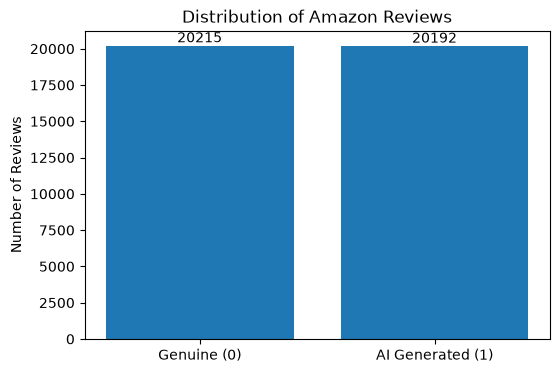

In [691]:
label_counts = amazon_df["label"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["Genuine (0)", "AI Generated (1)"], label_counts.values)
plt.title("Distribution of Amazon Reviews")
plt.ylabel("Number of Reviews")

for i, value in enumerate(label_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.show()

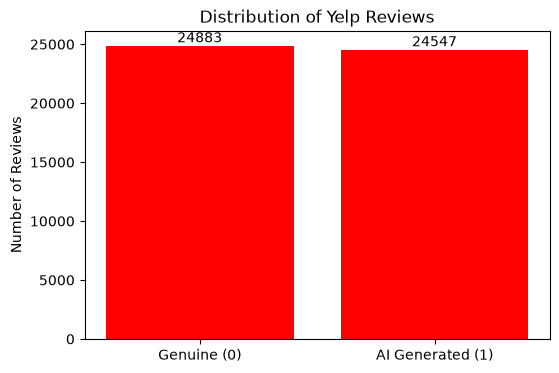

In [692]:
label_counts = yelp_sample["label"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["Genuine (0)", "AI Generated (1)"], label_counts.values,color="red")
plt.title("Distribution of Yelp Reviews")
plt.ylabel("Number of Reviews")

for i, value in enumerate(label_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.show()

### Feature Engineering

list the features being created: text_length, word_count, sentence_count, vocab_richness, avg_word_len

In [693]:
#feature engineering for amazon

amazon_df["text_length"] = amazon_df["review"].str.len()

amazon_df["word_count"] = amazon_df["review"].str.split().apply(len)

amazon_df["sentence_count"] = amazon_df["review"].apply(
    lambda x: len([s for s in nltk.sent_tokenize(x) if s.strip()])
)

amazon_df[["review","text_length", "word_count", "sentence_count"]].head()

,review,text_length,word_count,sentence_count
0,love this well made sturdy and very comfortable i love it very pretty,69,13,1
1,love it a great upgrade from the original i ve had mine for a couple of years,77,17,1
2,this pillow saved my back i love the look and feel of this pillow,65,14,1
3,missing information on how to use it but it is a great product for the price i,78,17,1
4,very nice set good quality we have had the set for two months now and have not been,83,18,1


In [694]:
#feature engineering for yelp

yelp_sample["text_length"] = yelp_sample["review"].str.len()

yelp_sample["word_count"] = yelp_sample["review"].str.split().apply(len)

yelp_sample["sentence_count"] = yelp_sample["review"].apply(
    lambda x: len([s for s in nltk.sent_tokenize(x) if s.strip()])
)

yelp_sample[["review","text_length", "word_count", "sentence_count"]].head()

,review,text_length,word_count,sentence_count
0,my wife and i were told to check this place out we did just that last week and it was off the chain good part upscale grocery but not overpriced part i just stepped into italy and part amazing res...,204,40,1
1,the atmosphere is really great with the open kitchen and all but the hostess bartender and so called owner were too cool for school esp when you we made a reservation on opentable for a specific t...,889,169,1
2,very regular thai food the drinks aren t bad but they re pretty weak we came on a friday night and it was really busy so maybe the service wasn t normal but it was pretty horrible no one came to o...,522,107,1
3,i m not one to trash companies and i have loved this restaurant for years this gives them 2 stars instead of 1 i m posting my email which received a response after 2 days claiming they would follo...,2489,487,1
4,my favorite of the 1 for 4 dumplings spot cause this place gives you 5 dumpling for a dollar and they re the juiciest and tastiest of the ones i ve tried,153,32,1


### Feature Distributions

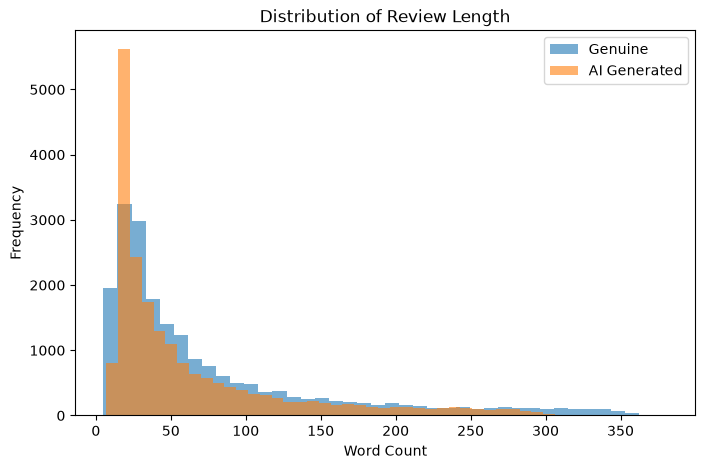

In [695]:
plt.figure(figsize=(8,5))

plt.hist(amazon_df[amazon_df["label"] == 0]["word_count"], bins=40, alpha=0.6, label="Genuine")

plt.hist(amazon_df[amazon_df["label"] == 1]["word_count"], bins=40, alpha=0.6, label="AI Generated")

plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Distribution of Review Length")
plt.legend()

plt.show()

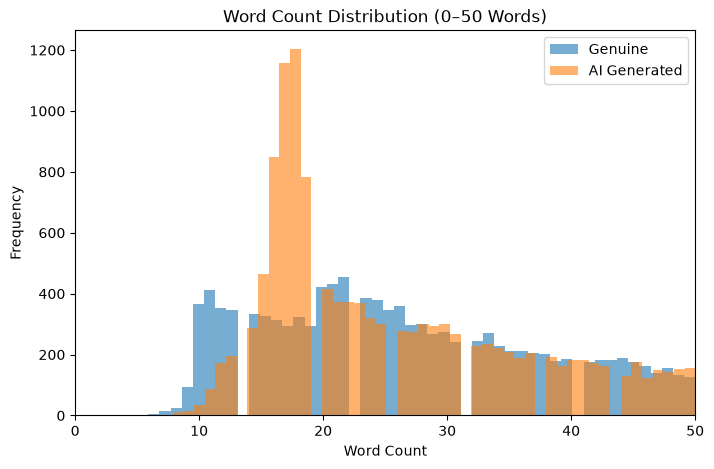

In [696]:
# Keep only reviews with <= 50 words
short_reviews = amazon_df[amazon_df["word_count"] <= 50]

plt.figure(figsize=(8,5))

plt.hist(
    short_reviews[short_reviews["label"] == 0]["word_count"],
    bins=50,                 # 1-word bins
    alpha=0.6,
    label="Genuine"
)

plt.hist(
    short_reviews[short_reviews["label"] == 1]["word_count"],
    bins=50,
    alpha=0.6,
    label="AI Generated"
)

plt.xlim(0, 50)
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Word Count Distribution (0–50 Words)")
plt.legend()

plt.show()

In [697]:
# AI-generated reviews with 10–20 words
ai_reviews_10_20 = amazon_df[
    (amazon_df["label"] == 1) &
    (amazon_df["word_count"].between(10, 20))
]

# Display the relevant columns
ai_reviews_10_20[["review", "word_count"]]

,review,word_count
0,love this well made sturdy and very comfortable i love it very pretty,13
1,love it a great upgrade from the original i ve had mine for a couple of years,17
2,this pillow saved my back i love the look and feel of this pillow,14
3,missing information on how to use it but it is a great product for the price i,17
4,very nice set good quality we have had the set for two months now and have not been,18
...,...,...
38168,beautiful bootie not real suede but the quality is good the only reason i ordered this is because i had,20
38227,great shoe very comfy and supportive great quality for the price i am 5 6 and the dress fit perfectly,20
38269,twelve cotton bandannas in white i love the look and fit of these i am 5 6 and the waistband,20
38273,cute wings but cheapy made for girls not worth it nice bag very pretty i bought this for my son,20


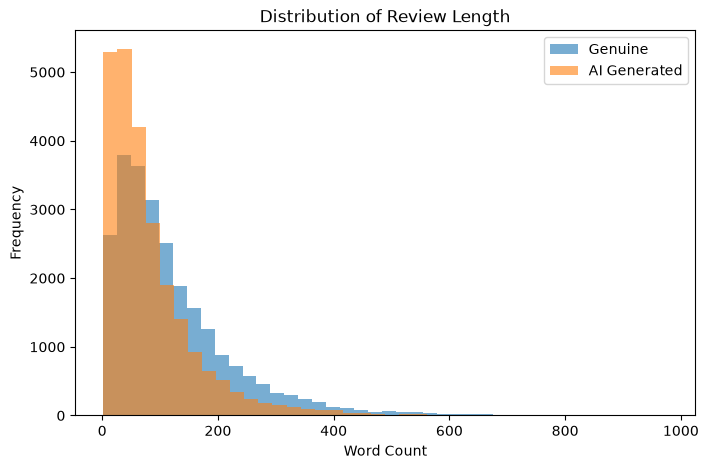

In [698]:
plt.figure(figsize=(8,5))

plt.hist(yelp_sample[yelp_sample["label"] == 0]["word_count"], bins=40, alpha=0.6, label="Genuine")

plt.hist(yelp_sample[yelp_sample["label"] == 1]["word_count"], bins=40, alpha=0.6, label="AI Generated")

plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Distribution of Review Length")
plt.legend()

plt.show()

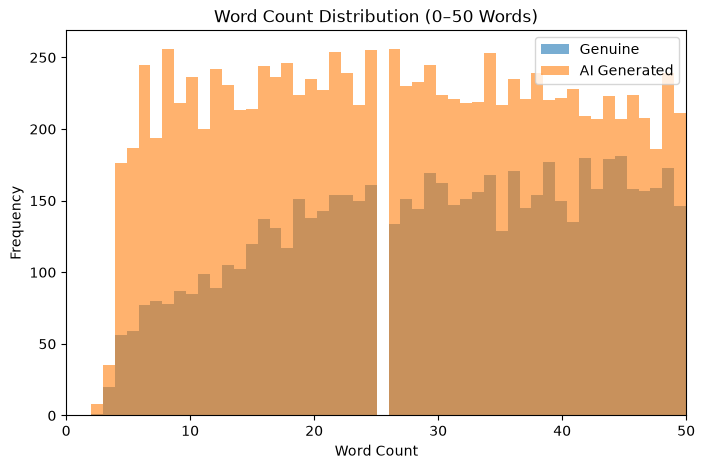

In [699]:
# Keep only reviews with <= 50 words
short_reviews = yelp_sample[yelp_sample["word_count"] <= 50]

plt.figure(figsize=(8,5))

plt.hist(
    short_reviews[short_reviews["label"] == 0]["word_count"],
    bins=50,                 # 1-word bins
    alpha=0.6,
    label="Genuine"
)

plt.hist(
    short_reviews[short_reviews["label"] == 1]["word_count"],
    bins=50,
    alpha=0.6,
    label="AI Generated"
)

plt.xlim(0, 50)
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Word Count Distribution (0–50 Words)")
plt.legend()

plt.show()

In [700]:
# AI-generated reviews with 10–20 words
ai_reviews_10_20 = yelp_sample[
    (yelp_sample["label"] == 1) &
    (yelp_sample["word_count"].between(10, 20))
]

# Display the relevant columns
ai_reviews_10_20[["review", "word_count"]]

,review,word_count
11,great burgers a bit of a too cool for school vibe but overall good experience,15
28,the best ramen i ve ever had really worth waiting for a long time,14
87,lively atmosphere great to go with a group of friends the burgers are delicious,14
93,sophies is amazing i can no lt get enough of there empanadas everything in there is delicious,17
133,a great japanese place for some japanese fusion cuisine whenever i go here this place never fails to amaze me,20
...,...,...
49863,i didnt like it ive tasted much better all bread and no meat,13
49870,great for sunday brunch loved sitting on the outside garden really good eggs benedict,14
49871,fantastic izakaya extensive sake menu great ambience excellent grilled squid miso rice balls and authentic japanese service,17
49919,absolutely the best coffee in the neighborhood quality sake served with a passion,13


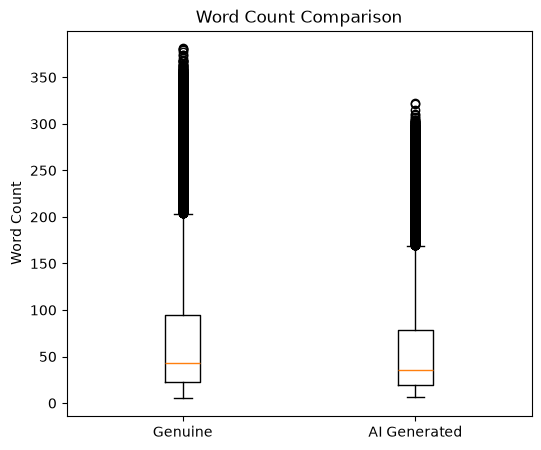

In [701]:
plt.figure(figsize=(6,5))

plt.boxplot(
    [
        amazon_df[amazon_df["label"] == 0]["word_count"],
        amazon_df[amazon_df["label"] == 1]["word_count"]
    ],
    tick_labels=["Genuine", "AI Generated"]
)

plt.ylabel("Word Count")
plt.title("Word Count Comparison")

plt.show()

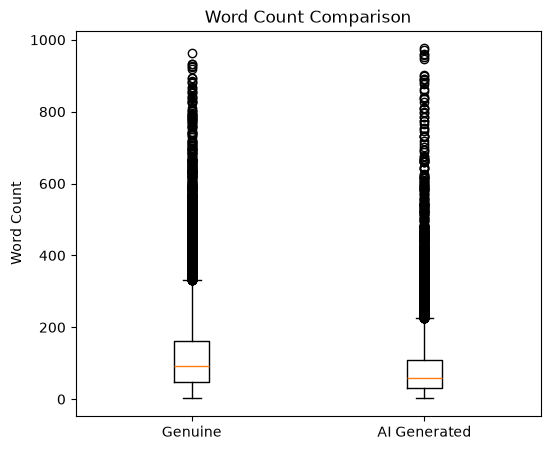

In [702]:
plt.figure(figsize=(6,5))

plt.boxplot(
    [
        yelp_sample[yelp_sample["label"] == 0]["word_count"],
        yelp_sample[yelp_sample["label"] == 1]["word_count"]
    ],
    tick_labels=["Genuine", "AI Generated"]
)

plt.ylabel("Word Count")
plt.title("Word Count Comparison")

plt.show()

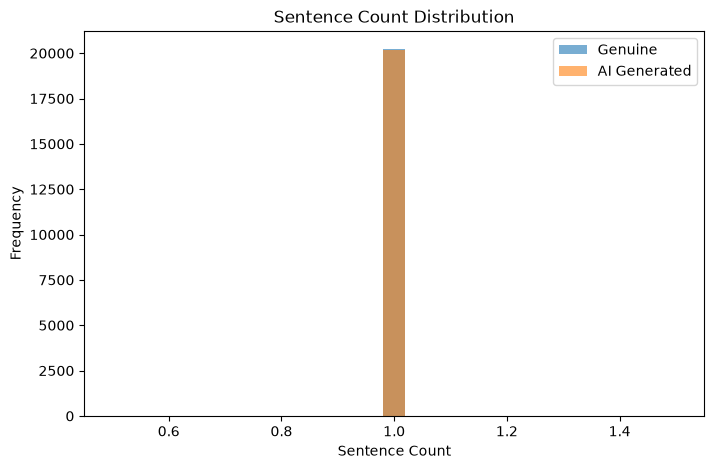

In [703]:
plt.figure(figsize=(8,5))

plt.hist(amazon_df[amazon_df["label"] == 0]["sentence_count"], bins=25, alpha=0.6, label="Genuine")

plt.hist(amazon_df[amazon_df["label"] == 1]["sentence_count"], bins=25, alpha=0.6, label="AI Generated")

plt.title("Sentence Count Distribution")
plt.xlabel("Sentence Count")
plt.ylabel("Frequency")
plt.legend()

plt.show()

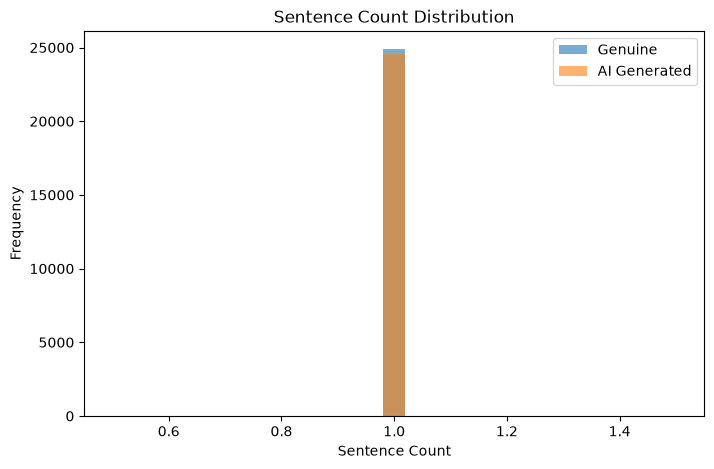

In [704]:
plt.figure(figsize=(8,5))

plt.hist(yelp_sample[yelp_sample["label"] == 0]["sentence_count"], bins=25, alpha=0.6, label="Genuine")

plt.hist(yelp_sample[yelp_sample["label"] == 1]["sentence_count"], bins=25, alpha=0.6, label="AI Generated")

plt.title("Sentence Count Distribution")
plt.xlabel("Sentence Count")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [705]:
def vocab_richness(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

amazon_df["vocab_richness"] = amazon_df["review"].apply(vocab_richness)

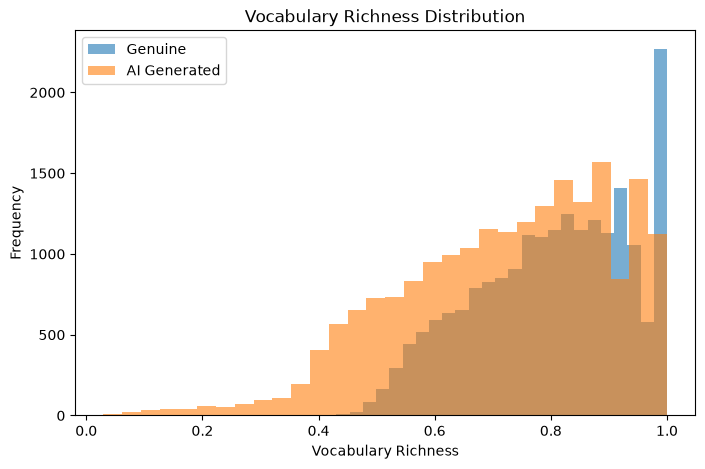

In [706]:
plt.figure(figsize=(8,5))

plt.hist(amazon_df[amazon_df["label"] == 0]["vocab_richness"], bins=30, alpha=0.6, label="Genuine")

plt.hist(amazon_df[amazon_df["label"] == 1]["vocab_richness"], bins=30, alpha=0.6, label="AI Generated")

plt.xlabel("Vocabulary Richness")
plt.ylabel("Frequency")
plt.title("Vocabulary Richness Distribution")
plt.legend()

plt.show()

In [707]:
def vocab_richness(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

yelp_sample["vocab_richness"] = yelp_sample["review"].apply(vocab_richness)

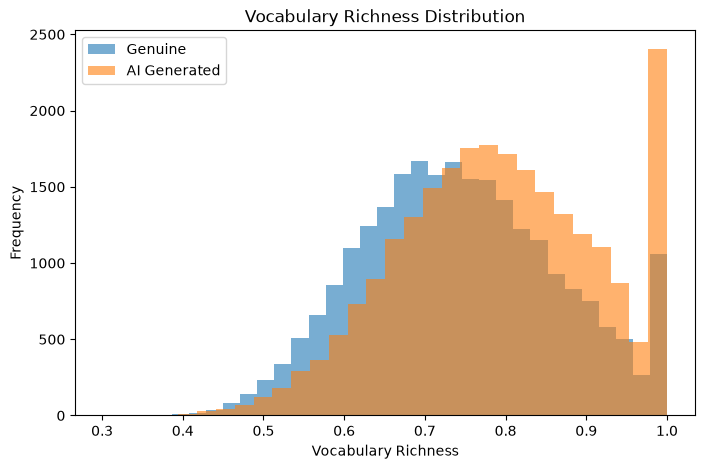

In [708]:
plt.figure(figsize=(8,5))

plt.hist(yelp_sample[yelp_sample["label"] == 0]["vocab_richness"], bins=30, alpha=0.6, label="Genuine")

plt.hist(yelp_sample[yelp_sample["label"] == 1]["vocab_richness"], bins=30, alpha=0.6, label="AI Generated")

plt.xlabel("Vocabulary Richness")
plt.ylabel("Frequency")
plt.title("Vocabulary Richness Distribution")
plt.legend()

plt.show()

In [709]:
def avg_word_length(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return np.mean([len(word) for word in words])

amazon_df["avg_word_len"] = amazon_df["review"].apply(avg_word_length)

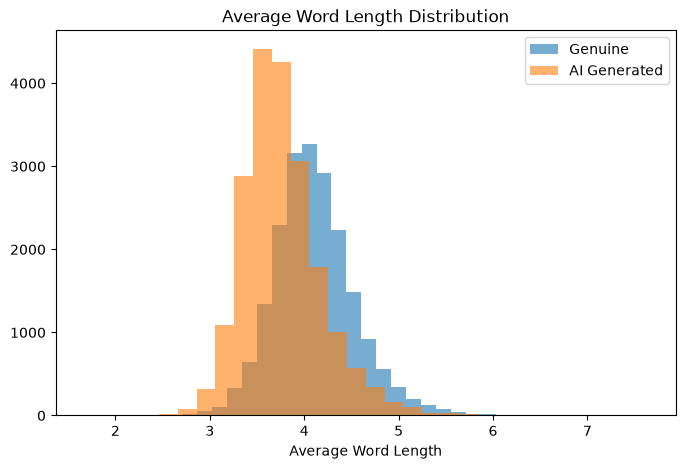

In [710]:
plt.figure(figsize=(8,5))

plt.hist(amazon_df[amazon_df["label"] == 0]["avg_word_len"], bins=30, alpha=0.6, label="Genuine")

plt.hist(amazon_df[amazon_df["label"] == 1]["avg_word_len"], bins=30, alpha=0.6, label="AI Generated")

plt.title("Average Word Length Distribution")
plt.xlabel("Average Word Length")
plt.legend()

plt.show()

In [711]:
def avg_word_length(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return np.mean([len(word) for word in words])

yelp_sample["avg_word_len"] = yelp_sample["review"].apply(avg_word_length)

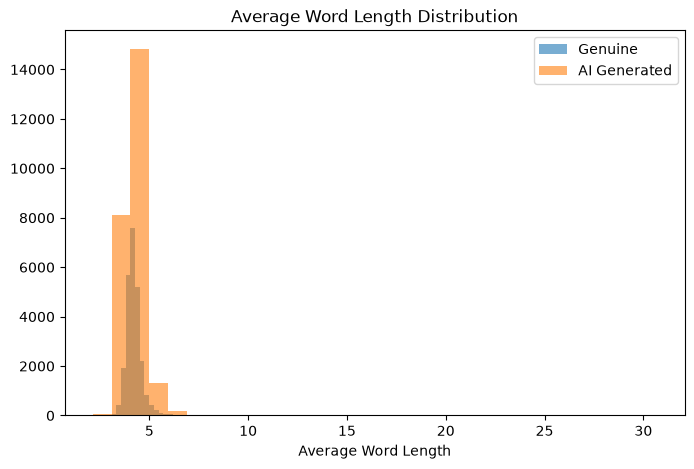

In [712]:
plt.figure(figsize=(8,5))

plt.hist(yelp_sample[yelp_sample["label"] == 0]["avg_word_len"], bins=30, alpha=0.6, label="Genuine")

plt.hist(yelp_sample[yelp_sample["label"] == 1]["avg_word_len"], bins=30, alpha=0.6, label="AI Generated")

plt.title("Average Word Length Distribution")
plt.xlabel("Average Word Length")
plt.legend()

plt.show()

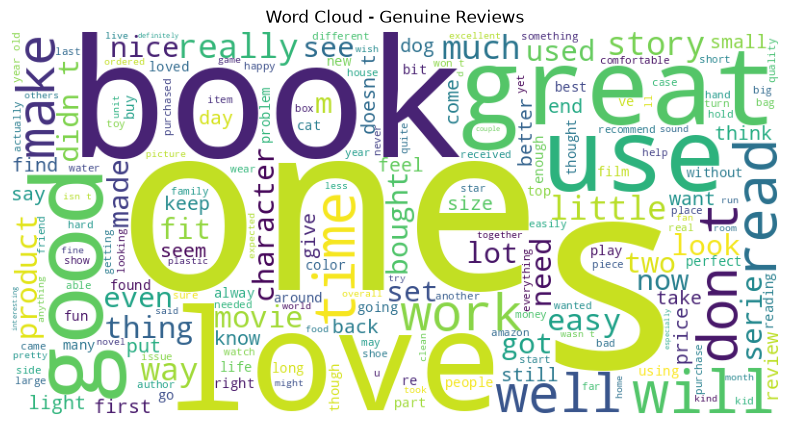

In [713]:
genuine_text = " ".join(amazon_df[amazon_df["label"] == 0]["review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(genuine_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud - Genuine Reviews")
plt.show()

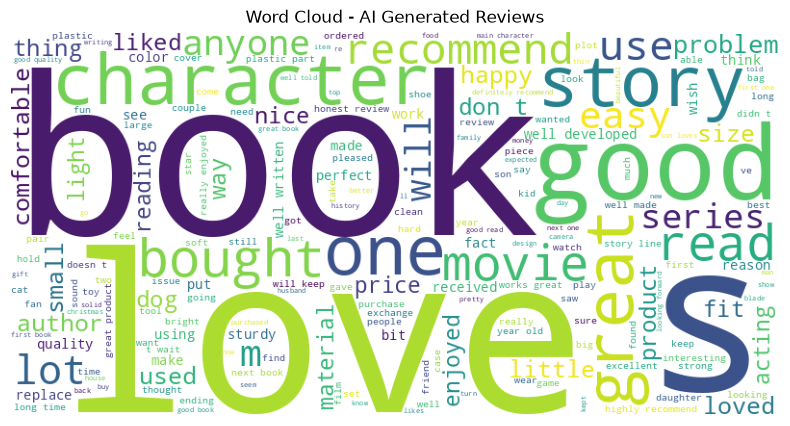

In [714]:
fake_text = " ".join(amazon_df[amazon_df["label"] == 1]["review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(fake_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud - AI Generated Reviews")
plt.show()

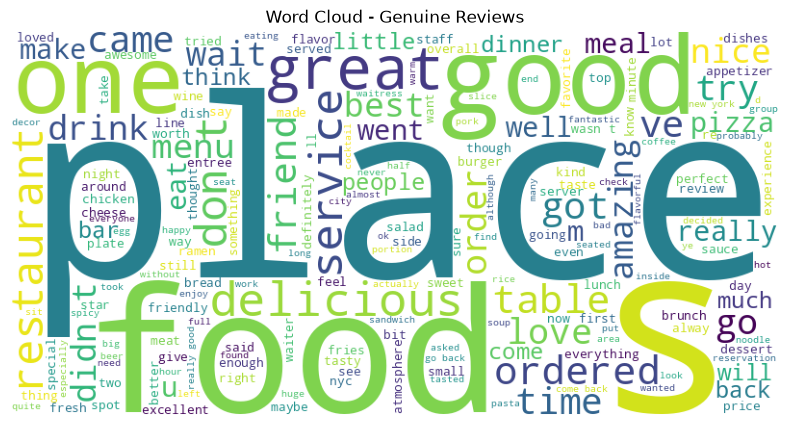

In [715]:
genuine_text = " ".join(yelp_sample[yelp_sample["label"] == 0]["review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(genuine_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud - Genuine Reviews")
plt.show()

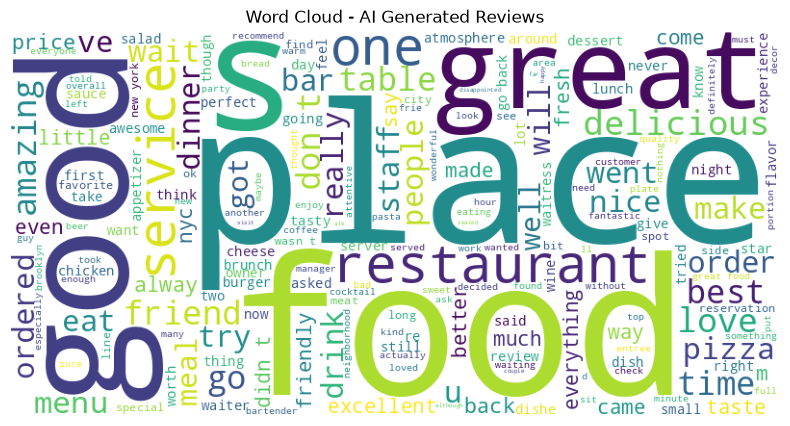

In [716]:
fake_text = " ".join(yelp_sample[yelp_sample["label"] == 1]["review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(fake_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud - AI Generated Reviews")
plt.show()

In [717]:
def plot_top_words(dataframe, label, title):
    vectorizer = CountVectorizer(stop_words="english", max_features=20)

    X = vectorizer.fit_transform(dataframe[dataframe["label"] == label]["review"])

    counts = np.asarray(X.sum(axis=0)).flatten()

    words = vectorizer.get_feature_names_out()

    pairs = sorted(zip(words, counts), key=lambda x: x[1], reverse=True)

    words, counts = zip(*pairs)

    plt.figure(figsize=(8,6))
    plt.barh(words, counts)
    plt.title(title)
    plt.xlabel("Frequency")
    plt.gca().invert_yaxis()
    plt.show()

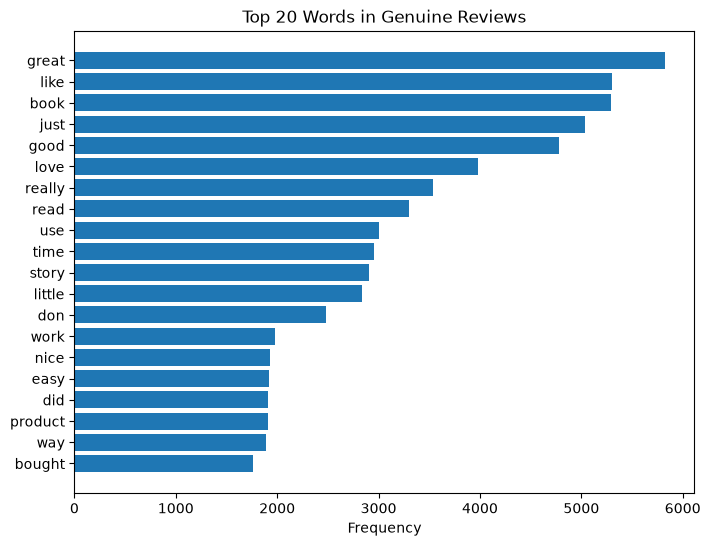

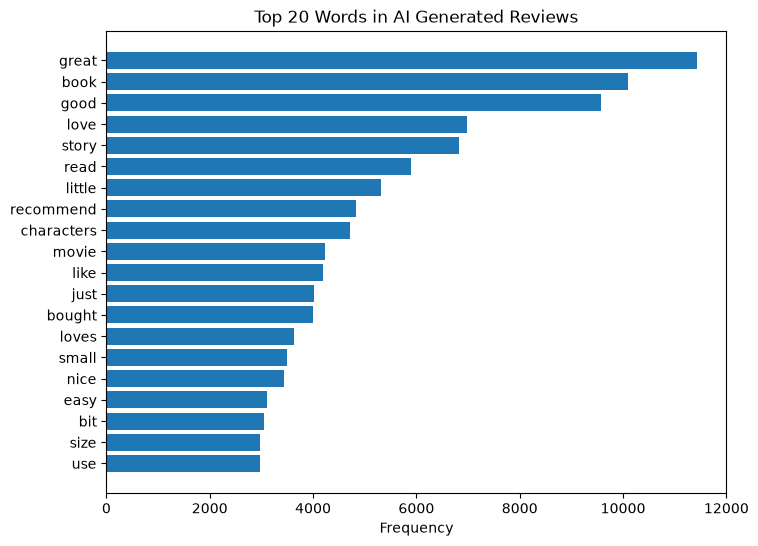

In [718]:
plot_top_words(amazon_df, 0, "Top 20 Words in Genuine Reviews")

plot_top_words(amazon_df, 1, "Top 20 Words in AI Generated Reviews")

In [719]:
amazon_df[
    amazon_df["review"].str.contains(r"\bcharacters\b", case=False, na=False)
][["review", "label", "word_count"]].sample(10, random_state=42)

,review,label,word_count
25740,i enjoyed this werewolf story the heroine is a wonderful character and her son s are sure to be strong characters in future books the hero is a well rounded character as well and i look forward to...,0,49
24464,i enjoyed the story i loved the characters i loved the history i enjoyed the way the author portrayed the characters,1,21
15012,this is a terrfic series that has the characters and plots of a science fiction story it has the appearance of a very dark and disturbing world the characters are not the same as the original movi...,1,155
31165,rick bragg is one of the most entertaining characters i ve read in a long time this is a very well written book and i am sure you ll enjoy it as much as i do it s a very well written story and i m...,1,68
27064,very good book and for a beginner the writing is good there is a lot of detail and so on i liked how the characters were developed the story line was interesting and the characters were well devel...,1,89
15028,this movie is available in both english and french which is a nice bonus i recommend it i really enjoyed the movie the characters and the story were great the acting was great the acting was great...,1,141
15283,dirty harry is more than a little predictable the two main characters are just too predictable and predictable the movie is also a bit too long and the first half is pretty straight forward the se...,1,201
26227,no one includes a better mix of action adventure romance and humor in one story than patti larsen and this installment of the blood gold series is no different i love larsen s writing and characte...,0,64
24942,i have enjoyed this author s work the characters are well developed and the story is well told the story is well written the characters are well,1,27
25639,wow this was an awesome book the characters were well developed and i enjoyed the story the writing is well done the story is well told and the flow of the story is well developed the author does ...,1,42


In [720]:
# Reviews containing the word "characters"
characters_reviews = amazon_df[
    amazon_df["review"].str.contains(r"\bcharacters\b", case=False, na=False)
]

# Count of Genuine (0) and AI Generated (1)
label_counts = characters_reviews["label"].value_counts().sort_index()

print("Label Distribution:")
print(label_counts)

print("\nPercentage Distribution:")
print((label_counts / len(characters_reviews) * 100).round(2))

Label Distribution:
label
0    1130
1    2567
Name: count, dtype: int64

Percentage Distribution:
label
0    30.57
1    69.43
Name: count, dtype: float64


In [721]:
# Reviews containing the word "recommend"
recommend_reviews = amazon_df[
    amazon_df["review"].str.contains(r"\brecommend\b", case=False, na=False)
]

# Count of Genuine (0) and AI Generated (1)
label_counts = recommend_reviews["label"].value_counts().sort_index()

print("Label Distribution:")
print(label_counts)

print("\nPercentage Distribution:")
print((label_counts / len(recommend_reviews) * 100).round(2))

Label Distribution:
label
0    1373
1    3424
Name: count, dtype: int64

Percentage Distribution:
label
0    28.62
1    71.38
Name: count, dtype: float64


These 2 words recommend and characters where very prominently used by AI to write the review on the other hand humans didn't use these words as much.

Side Note: - This also tells us one thing without checking the category in which fake reviews are more common than the others. Since, "characters" word were used so often by AI its safe to say AI generated reviews are very common in books category.

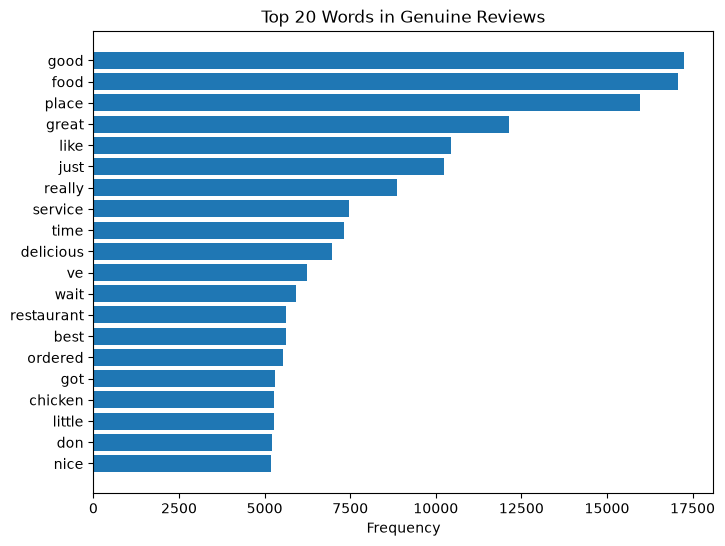

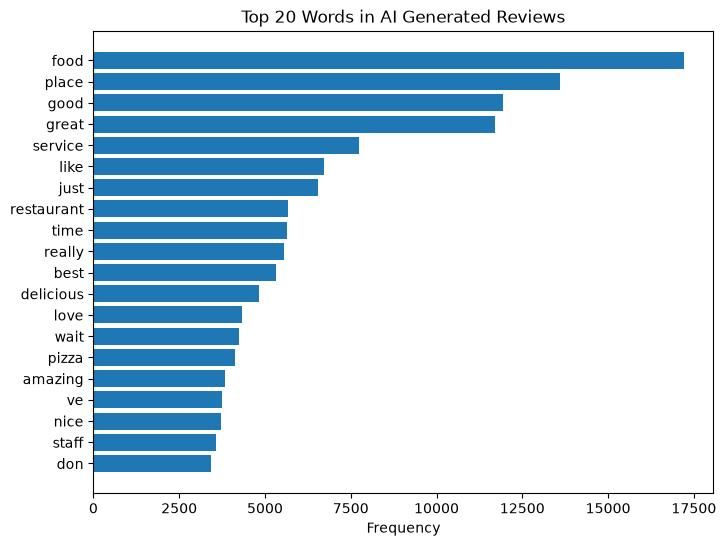

In [722]:
plot_top_words(yelp_sample, 0, "Top 20 Words in Genuine Reviews")

plot_top_words(yelp_sample, 1, "Top 20 Words in AI Generated Reviews")

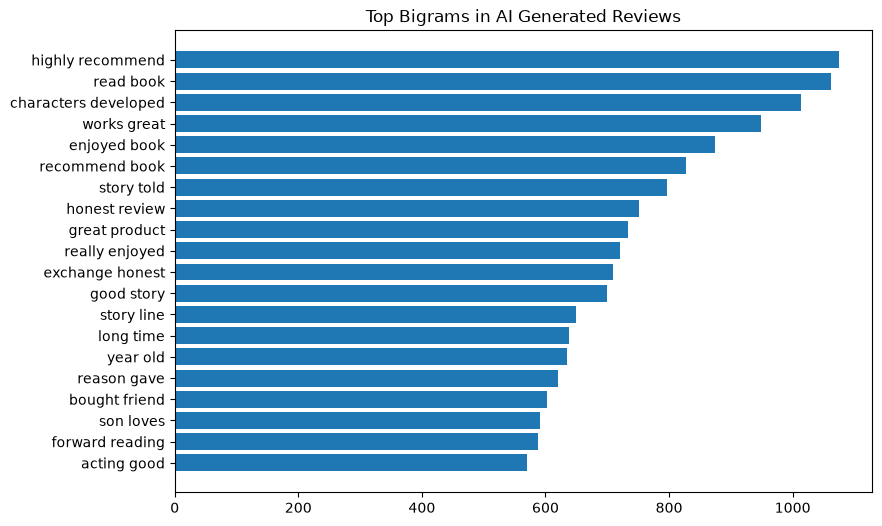

In [723]:
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    max_features=20
)

X = vectorizer.fit_transform(amazon_df[amazon_df["label"] == 1]["review"])

counts = np.asarray(X.sum(axis=0)).flatten()

bigrams = vectorizer.get_feature_names_out()

pairs = sorted(zip(bigrams, counts), key=lambda x: x[1], reverse=True)

bigrams, counts = zip(*pairs)

plt.figure(figsize=(9,6))
plt.barh(bigrams, counts)
plt.title("Top Bigrams in AI Generated Reviews")
plt.gca().invert_yaxis()
plt.show()

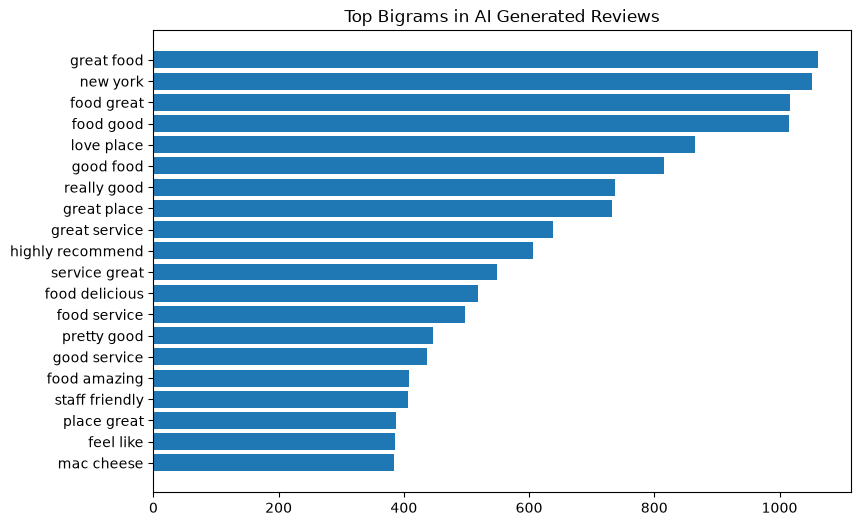

In [724]:
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    max_features=20
)

X = vectorizer.fit_transform(yelp_sample[yelp_sample["label"] == 1]["review"])

counts = np.asarray(X.sum(axis=0)).flatten()

bigrams = vectorizer.get_feature_names_out()

pairs = sorted(zip(bigrams, counts), key=lambda x: x[1], reverse=True)

bigrams, counts = zip(*pairs)

plt.figure(figsize=(9,6))
plt.barh(bigrams, counts)
plt.title("Top Bigrams in AI Generated Reviews")
plt.gca().invert_yaxis()
plt.show()

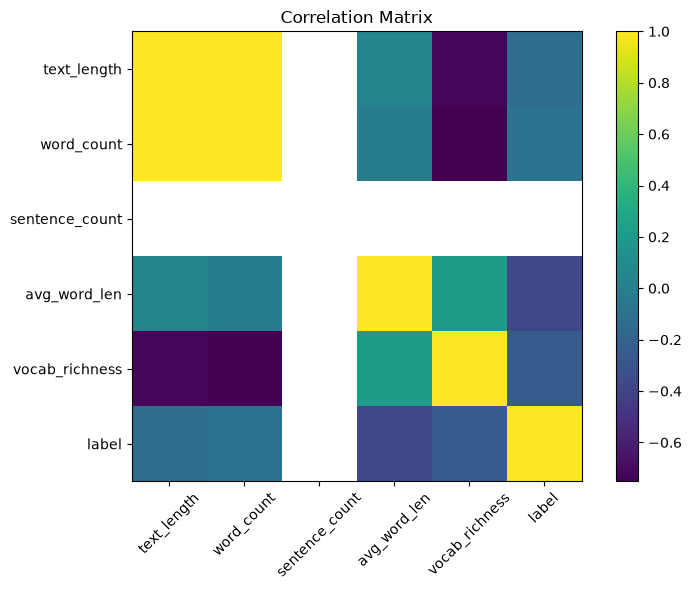

In [725]:
feature_cols = [
    "text_length",
    "word_count",
    "sentence_count",
    "avg_word_len",
    "vocab_richness",
    "label"
]

corr = amazon_df[feature_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(feature_cols)), feature_cols, rotation=45)

plt.yticks(range(len(feature_cols)), feature_cols)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

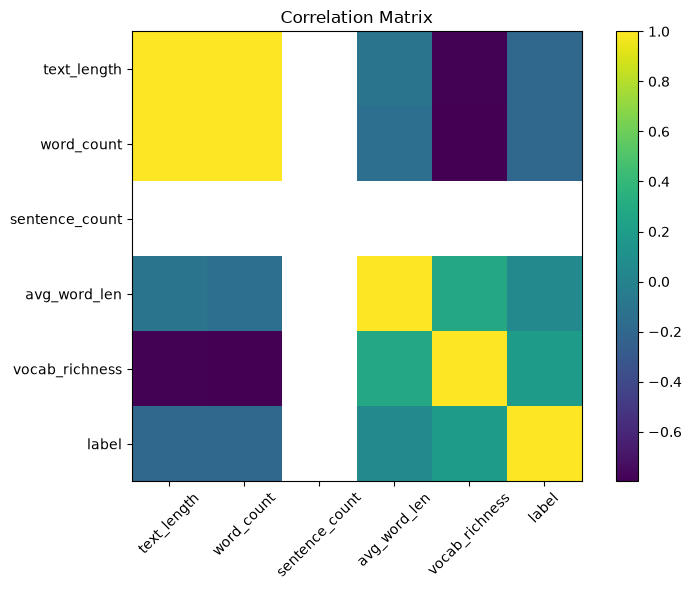

In [726]:
feature_cols = [
    "text_length",
    "word_count",
    "sentence_count",
    "avg_word_len",
    "vocab_richness",
    "label"
]

corr = yelp_sample[feature_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(feature_cols)), feature_cols, rotation=45)

plt.yticks(range(len(feature_cols)), feature_cols)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [727]:
summary = amazon_df.groupby("label")[
    [
        "text_length",
        "word_count",
        "sentence_count",
        "avg_word_len",
        "vocab_richness"
    ]
].describe()

summary

text_length                                                             \
            count        mean         std   min    25%    50%    75%     max   
label                                                                          
0         20215.0  383.558348  402.202223  24.0  117.0  217.0  484.0  2095.0   
1         20192.0  296.262827  298.076633  37.0   93.0  169.0  370.0  1665.0   

      word_count                                                      \
           count       mean        std  min   25%   50%   75%    max   
label                                                                  
0        20215.0  75.199159  77.811015  5.0  23.0  43.0  95.0  381.0   
1        20192.0  63.140055  63.753927  7.0  19.0  36.0  79.0  322.0   

      sentence_count                                    avg_word_len  \
               count mean  std  min  25%  50%  75%  max        count   
label                                                                  
0            20215.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0      20215.0   
1            20192.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0      20192.0   

                                                                             \
           mean       std       min       25%       50%       75%       max   
label                                                                         
0      4.109831  0.436404  2.545455  3.827659  4.074074  4.352941  7.300000   
1      3.765257  0.419527  1.666667  3.488372  3.714286  3.977549  7.636364   

      vocab_richness                                                    \
               count      mean       std       min       25%       50%   
label                                                                    
0            20215.0  0.803361  0.133560  0.317073  0.704545  0.815789   
1            20192.0  0.721480  0.182635  0.029412  0.593750  0.750000   

                      
            75%  max  
label                 
0      0.909091  1.0  
1      0.869565  1.0

In [728]:
amazon_df.groupby("label")["vocab_richness"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,20215.0,0.803361,0.133560,0.317073,0.704545,0.815789,0.909091,1.0
1,20192.0,0.721480,0.182635,0.029412,0.593750,0.750000,0.869565,1.0


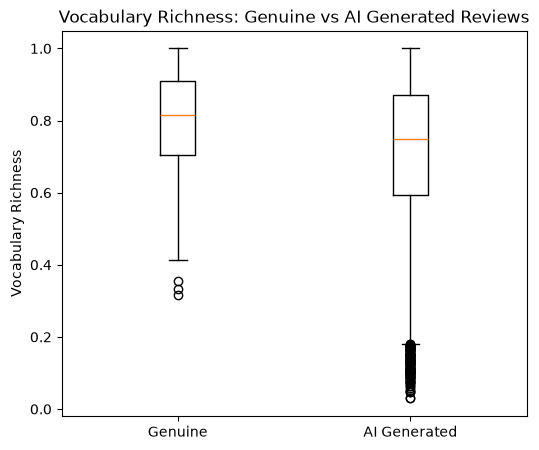

In [729]:
plt.figure(figsize=(6,5))

plt.boxplot(
    [
        amazon_df[amazon_df["label"] == 0]["vocab_richness"],
        amazon_df[amazon_df["label"] == 1]["vocab_richness"]
    ],
    tick_labels=["Genuine", "AI Generated"]
)

plt.title("Vocabulary Richness: Genuine vs AI Generated Reviews")
plt.ylabel("Vocabulary Richness")

plt.show()

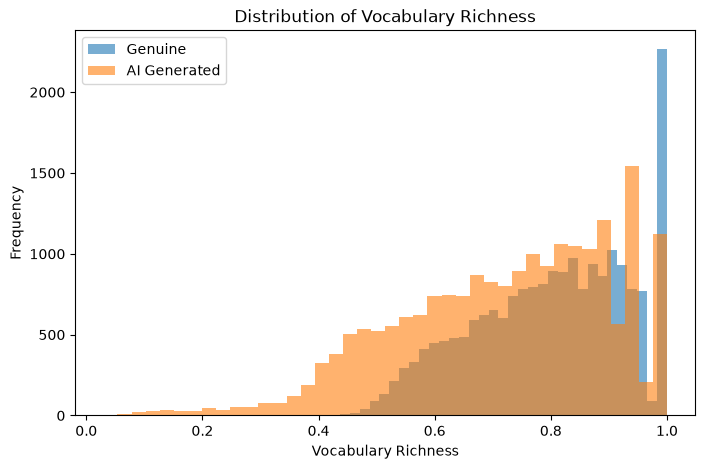

In [730]:
plt.figure(figsize=(8,5))

plt.hist(
    amazon_df[amazon_df["label"] == 0]["vocab_richness"],
    bins=40,
    alpha=0.6,
    label="Genuine"
)

plt.hist(
    amazon_df[amazon_df["label"] == 1]["vocab_richness"],
    bins=40,
    alpha=0.6,
    label="AI Generated"
)

plt.xlabel("Vocabulary Richness")
plt.ylabel("Frequency")
plt.title("Distribution of Vocabulary Richness")
plt.legend()

plt.show()

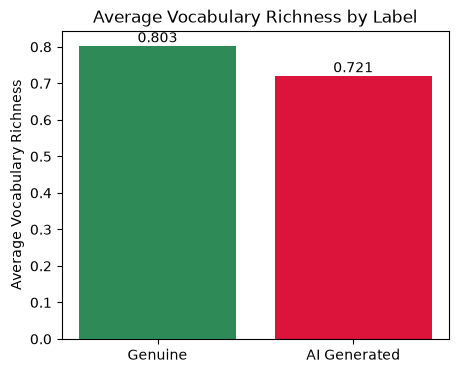

In [731]:
vocab_mean = amazon_df.groupby("label")["vocab_richness"].mean()

plt.figure(figsize=(5,4))

plt.bar(
    ["Genuine", "AI Generated"],
    vocab_mean.values,
    color=["#2E8B57", "#DC143C"]
)

plt.ylabel("Average Vocabulary Richness")
plt.title("Average Vocabulary Richness by Label")

for i, value in enumerate(vocab_mean.values):
    plt.text(i, value, f"{value:.3f}", ha="center", va="bottom")

plt.show()

This is interesting AI reviews have lower vocab richness than i thought would be the case.<br>
A guess i can take is in order to look like geniune ai generated review might delibratly reduce their own vocabulary.<br>
looking at the box plot and distribution graph. i believe my assumption is correct since human reviews didnt fall below a certain point(0.3). and even in the range of 0.3 there were very few examples which we can also rule as outliers.

In [732]:
summary = yelp_sample.groupby("label")[
    [
        "text_length",
        "word_count",
        "sentence_count",
        "avg_word_len",
        "vocab_richness"
    ]
].describe()

summary

text_length                                                             \
            count        mean         std   min    25%    50%    75%     max   
label                                                                          
0         24883.0  634.296267  563.243612  20.0  255.0  474.0  831.0  4848.0   
1         24547.0  436.217705  444.094634  20.0  157.0  306.0  559.0  4907.0   

      word_count                                                        \
           count        mean        std  min   25%   50%    75%    max   
label                                                                    
0        24883.0  123.018165  108.85437  2.0  49.0  92.0  162.0  964.0   
1        24547.0   84.416996   86.13125  2.0  30.0  59.0  108.0  976.0   

      sentence_count                                    avg_word_len  \
               count mean  std  min  25%  50%  75%  max        count   
label                                                                  
0            24883.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0      24883.0   
1            24547.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0      24547.0   

                                                                              \
           mean       std       min       25%       50%       75%        max   
label                                                                          
0      4.213053  0.396267  2.375000  3.975475  4.166667  4.391304   9.500000   
1      4.254301  0.515841  2.142857  3.965517  4.192308  4.461538  30.666667   

      vocab_richness                                                   \
               count      mean       std       min      25%       50%   
label                                                                   
0            24883.0  0.744078  0.122175  0.365488  0.65625  0.738318   
1            24547.0  0.790980  0.124140  0.301546  0.70339  0.789474   

                      
            75%  max  
label                 
0      0.828348  1.0  
1      0.882353  1.0

In [733]:
yelp_sample.groupby("label")["vocab_richness"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,24883.0,0.744078,0.122175,0.365488,0.65625,0.738318,0.828348,1.0
1,24547.0,0.790980,0.124140,0.301546,0.70339,0.789474,0.882353,1.0


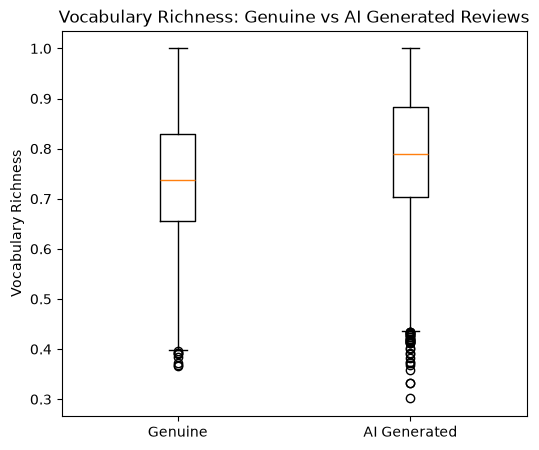

In [734]:
plt.figure(figsize=(6,5))

plt.boxplot(
    [
        yelp_sample[yelp_sample["label"] == 0]["vocab_richness"],
        yelp_sample[yelp_sample["label"] == 1]["vocab_richness"]
    ],
    tick_labels=["Genuine", "AI Generated"]
)

plt.title("Vocabulary Richness: Genuine vs AI Generated Reviews")
plt.ylabel("Vocabulary Richness")

plt.show()

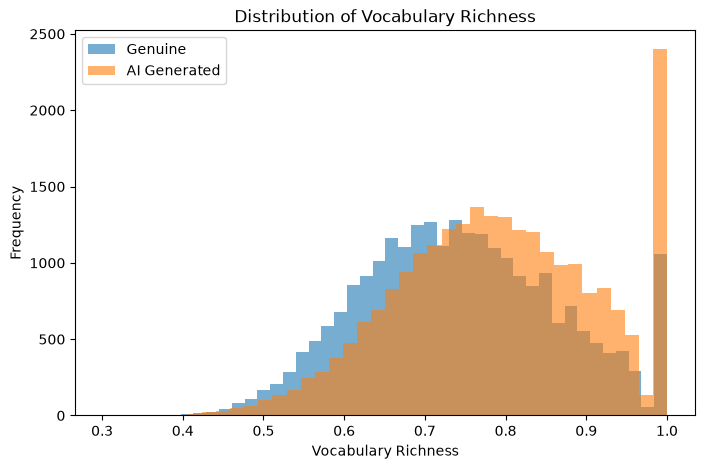

In [735]:
plt.figure(figsize=(8,5))

plt.hist(
    yelp_sample[yelp_sample["label"] == 0]["vocab_richness"],
    bins=40,
    alpha=0.6,
    label="Genuine"
)

plt.hist(
    yelp_sample[yelp_sample["label"] == 1]["vocab_richness"],
    bins=40,
    alpha=0.6,
    label="AI Generated"
)

plt.xlabel("Vocabulary Richness")
plt.ylabel("Frequency")
plt.title("Distribution of Vocabulary Richness")
plt.legend()

plt.show()

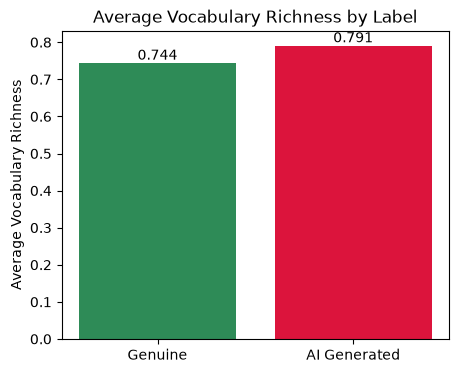

In [736]:
vocab_mean = yelp_sample.groupby("label")["vocab_richness"].mean()

plt.figure(figsize=(5,4))

plt.bar(
    ["Genuine", "AI Generated"],
    vocab_mean.values,
    color=["#2E8B57", "#DC143C"]
)

plt.ylabel("Average Vocabulary Richness")
plt.title("Average Vocabulary Richness by Label")

for i, value in enumerate(vocab_mean.values):
    plt.text(i, value, f"{value:.3f}", ha="center", va="bottom")

plt.show()

The Yelp dataset shows a different pattern from the Amazon dataset. Overall, AI-generated reviews have higher vocabulary richness than genuine human reviews, suggesting they tend to use a wider variety of unique words.<br>

However, genuine human reviews still follow a consistent distribution. From the box plot and histogram, most human reviews do not have a vocabulary richness below 0.4, with only a small number of reviews falling below this threshold. These can reasonably be treated as outliers rather than the general behavior of human-written reviews.